# 01 - Exploratory Data Analysis (EDA)

Loading and exploring the CIC-DDoS2019 dataset for multi-class classification.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_style("whitegrid")
%matplotlib inline

## Load Data (with sampling)

In [2]:
# Configuration
DATA_DIR = "../data/raw/CSVs"

# Find all CSV files
all_csv_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
print(f"Found {len(all_csv_files)} CSV files")
for f in all_csv_files:
    print(f"  - {f}")

Found 18 CSV files
  - ../data/raw/CSVs/01-12/DrDoS_NTP.csv
  - ../data/raw/CSVs/01-12/Syn.csv
  - ../data/raw/CSVs/01-12/DrDoS_DNS.csv
  - ../data/raw/CSVs/01-12/TFTP.csv
  - ../data/raw/CSVs/01-12/UDPLag.csv
  - ../data/raw/CSVs/01-12/DrDoS_SSDP.csv
  - ../data/raw/CSVs/01-12/DrDoS_NetBIOS.csv
  - ../data/raw/CSVs/01-12/DrDoS_MSSQL.csv
  - ../data/raw/CSVs/01-12/DrDoS_UDP.csv
  - ../data/raw/CSVs/01-12/DrDoS_LDAP.csv
  - ../data/raw/CSVs/01-12/DrDoS_SNMP.csv
  - ../data/raw/CSVs/03-11/Syn.csv
  - ../data/raw/CSVs/03-11/MSSQL.csv
  - ../data/raw/CSVs/03-11/UDPLag.csv
  - ../data/raw/CSVs/03-11/LDAP.csv
  - ../data/raw/CSVs/03-11/UDP.csv
  - ../data/raw/CSVs/03-11/Portmap.csv
  - ../data/raw/CSVs/03-11/NetBIOS.csv


In [18]:
SAMPLE_ROWS = 0  # rows sampled at random from CSV file, 0 if all
N_ROWS = 0  # first N rows from CSV file, 0 if all
RANDOM_STATE = 42 # for sampling

csv_directory = '../data/raw/CSVs/01-12/'
_csv_files = ['DrDoS_NTP.csv', 'UDPLag.csv', 'Syn.csv'] # Leave empty for all files
csv_files = [csv_directory + file for file in _csv_files]
# csv_files = all_csv_files # If You want to laod all files

# Load and sample data
def load_and_sample(filepath, nrows=N_ROWS, sample_rows=SAMPLE_ROWS, random_state=RANDOM_STATE):
    """Load CSV with optional sampling."""
    if nrows > 0:
        df = pd.read_csv(filepath, delimiter=',', nrows=nrows)
    else:
        df = pd.read_csv(filepath, delimiter=',')

    df.columns = df.columns.str.strip()

    if len(df) > sample_rows > 0:
        return df.sample(n=sample_rows, random_state=random_state)
    return df

# Load files
dfs = {}
for f in csv_files:
    base_name = os.path.basename(f)
    print(f"Loading {base_name}...")
    df = load_and_sample(f)
    dfs[base_name] = df
    print(f"  -> {len(df)} rows")

# Combine
df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nTotal: {len(df):,} rows, {df.shape[1]} columns")

Loading DrDoS_NTP.csv...


/var/folders/_5/rd93j0_50qx24_jwt4qyyl700000gp/T/ipykernel_94784/4056351257.py:16: DtypeWarning: Columns (0: SimillarHTTP) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, delimiter=',')


  -> 1217007 rows
Loading UDPLag.csv...
  -> 370605 rows
Loading Syn.csv...
  -> 1582681 rows

Total: 3,170,293 rows, 88 columns


In [ ]:
# Basic info
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes.value_counts())

Columns:
['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,0,172.16.0.5-192.168.50.1-60675-80-6,172.16.0.5,60675,192.168.50.1,80,6,2018-12-01 09:17:11.183810,5220876,12,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,205.174.165.72/c.php,1,DrDoS_NTP
1,7,172.16.0.5-192.168.50.1-60676-80-6,172.16.0.5,60676,192.168.50.1,80,6,2018-12-01 09:17:11.205636,12644252,5,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,DrDoS_NTP
2,12858,192.168.50.7-65.55.163.78-50458-443-6,65.55.163.78,443,192.168.50.7,50458,6,2018-12-01 09:17:12.634569,3,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,BENIGN
3,10191,192.168.50.7-65.55.163.78-50465-443-6,65.55.163.78,443,192.168.50.7,50465,6,2018-12-01 09:17:13.458370,3,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,BENIGN
4,239,192.168.50.253-224.0.0.5-0-0-0,192.168.50.253,0,224.0.0.5,0,0,2018-12-01 09:17:13.470913,114329232,52,...,2.466441,15.0,6.0,9527428.0,248706.681286,9950741.0,9092248.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3170288,432793,172.16.0.5-192.168.50.1-43299-42563-6,172.16.0.5,43299,192.168.50.1,42563,6,2018-12-01 13:34:27.402384,1,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,Syn
3170289,514566,172.16.0.5-192.168.50.1-43300-58948-6,172.16.0.5,43300,192.168.50.1,58948,6,2018-12-01 13:34:27.402386,1,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,Syn
3170290,147509,172.16.0.5-192.168.50.1-43301-52300-6,172.16.0.5,43301,192.168.50.1,52300,6,2018-12-01 13:34:27.402451,1,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,Syn
3170291,46401,172.16.0.5-192.168.50.1-43302-40846-6,172.16.0.5,43302,192.168.50.1,40846,6,2018-12-01 13:34:27.403142,1,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,Syn


## Source IP Distribution

In [ ]:
# Source IP distribution
ip_counts = df['Source IP'].value_counts()
print("Source IP distribution:")
print(ip_counts)
print(f"\nUnique IPs: {df['Source IP'].nunique()}")

Source IP distribution:
Source IP
172.16.0.5         3148785
192.168.50.7          6004
192.168.50.6          4475
192.168.50.8          4341
192.168.50.1          3177
                    ...   
23.206.171.185           1
23.194.110.144           1
173.194.175.109          1
104.110.151.222          1
52.36.47.72              1
Name: count, Length: 362, dtype: int64

Unique IPs: 362


## Source Label Distribution

In [23]:
# Source IP distribution
label_counts = df['Label'].value_counts()
print("Source IP distribution:")
print(label_counts)
print(f"\nUnique IPs: {df['Label'].nunique()}")

Source IP distribution:
Label
Syn          1582289
DrDoS_NTP    1202642
UDP-lag       366461
BENIGN         18462
WebDDoS          439
Name: count, dtype: int64

Unique IPs: 5


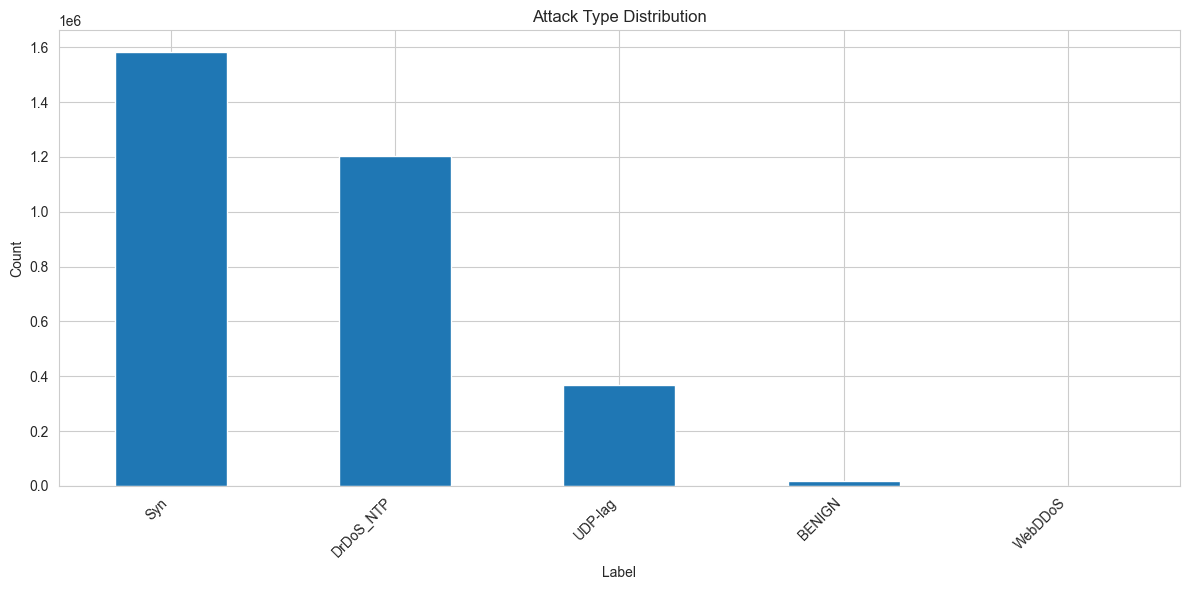

In [26]:
# Plot label distribution
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Attack Type Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/label_distribution.png', dpi=150)
plt.show()

## Key Features: Duration, Packet Count, Header Size

In [27]:
# Focus features (from CICFlowMeter)
KEY_FEATURES = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Header Length',
    'Bwd Header Length',
    'Protocol',
    'Flow Bytes/s',
    'Flow Packets/s'
]

# Check which exist
available_features = [f for f in KEY_FEATURES if f in df.columns]
print(f"Available key features: {len(available_features)}")
for f in available_features:
    print(f"  - {f}")

Available key features: 8
  - Flow Duration
  - Total Fwd Packets
  - Total Backward Packets
  - Fwd Header Length
  - Bwd Header Length
  - Protocol
  - Flow Bytes/s
  - Flow Packets/s


In [28]:
# Summary stats for key features
print(df[available_features].describe())

/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       Flow Duration  Total Fwd Packets  Total Backward Packets  \
count   3.170293e+06       3.170293e+06            3.170293e+06   
mean    4.703131e+06       2.608051e+01            2.362081e-01   
std     1.999874e+07       4.993956e+01            3.892264e+00   
min     0.000000e+00       1.000000e+00            0.000000e+00   
25%     1.000000e+00       2.000000e+00            0.000000e+00   
50%     4.900000e+01       2.000000e+00            0.000000e+00   
75%     1.163000e+03       2.200000e+01            0.000000e+00   
max     1.200000e+08       8.456000e+03            1.862000e+03   

       Fwd Header Length  Bwd Header Length      Protocol  Flow Bytes/s  \
count       3.170293e+06       3.170293e+06  3.170293e+06  2.931853e+06   
mean       -1.727254e+08      -8.040200e+03  1.035602e+01           inf   
std         4.713626e+09       4.135125e+06  5.381106e+00           NaN   
min        -2.125438e+11      -2.125438e+09  0.000000e+00  0.000000e+00   
25%         4.000000e

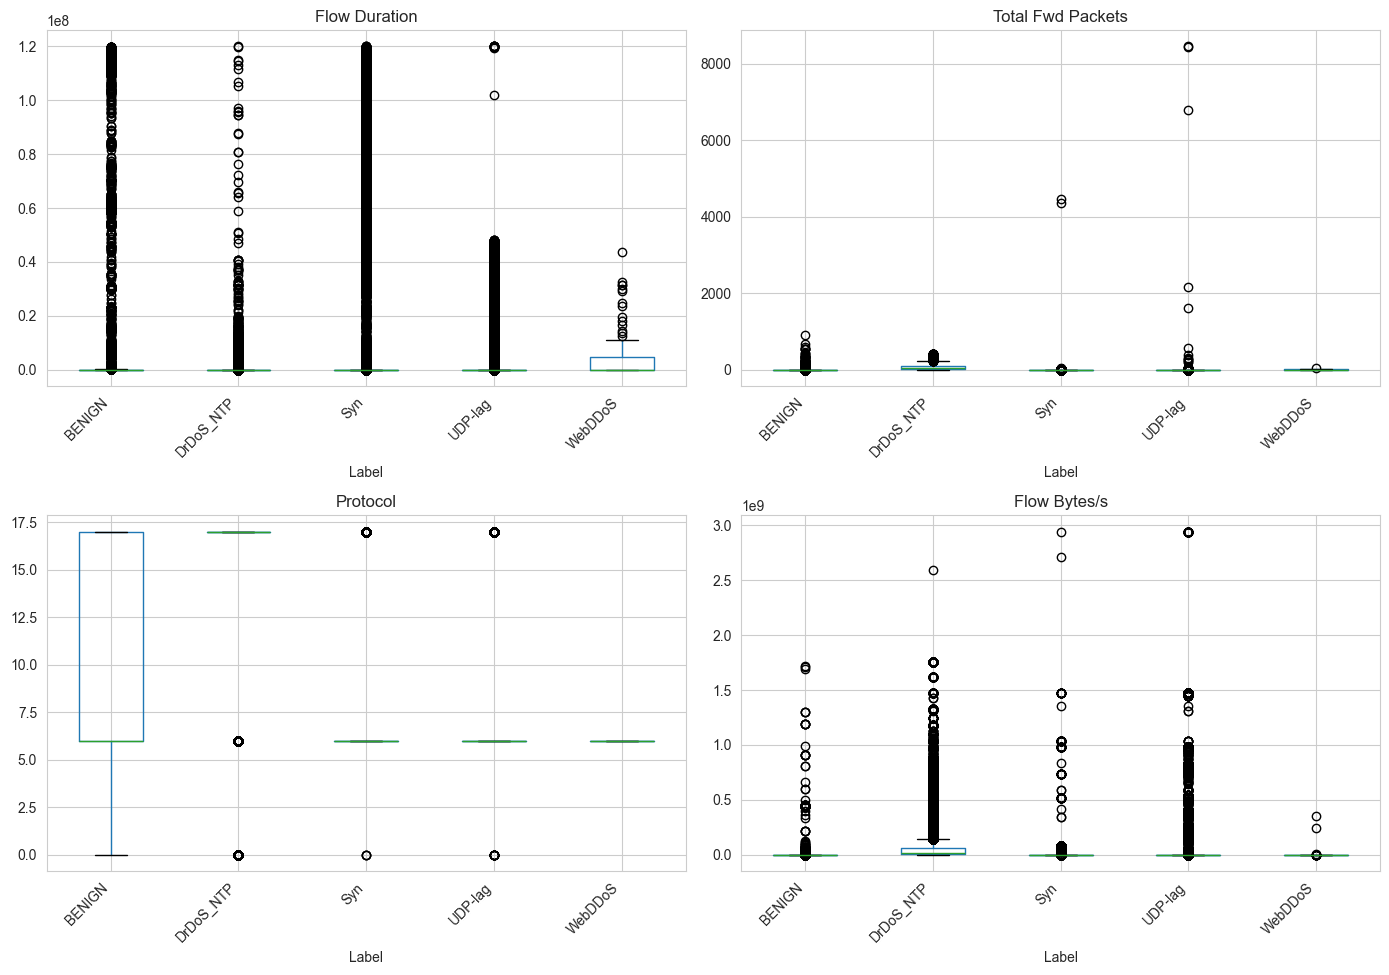

In [30]:
# Boxplots by attack type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = ['Flow Duration', 'Total Fwd Packets', 'Protocol', 'Flow Bytes/s']
for ax, feat in zip(axes.flatten(), features_to_plot):
    if feat in df.columns:
        df.boxplot(column=feat, by='Label', ax=ax)
        ax.set_title(feat)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/figures/features_boxplot.png', dpi=150)
plt.show()

## Save Processed Data

In [32]:
# Save sampled data
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)
df.to_csv(f"{output_dir}/ddos_sampled.csv", index=False)
print(f"Saved {len(df):,} rows to {output_dir}/ddos_sampled.csv")

Saved 3,170,293 rows to ../data/processed/ddos_sampled.csv
